<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/1_intro_aa_micaela_sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 1 – Actividad Práctica Integrada
## Introducción al Aprendizaje Automático

En esta actividad exploraremos un dataset simple, identificaremos el tipo de aprendizaje adecuado, entrenaremos nuestro primer modelo con scikit‑learn y resolveremos dos desafíos gamificados.

## Formalización matemática del aprendizaje supervisado

En un problema de **aprendizaje supervisado**, contamos con un conjunto de datos:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n
$$

donde:

-  $$ x_i \in \mathbb{R}^d $$ es un vector de atributos,
-  $$ y_i $$ es la etiqueta o variable objetivo.

El objetivo del modelo es aprender una función:

$$
f_\theta : \mathbb{R}^d \rightarrow \mathcal{Y}
$$

parametrizada por $ \theta $, tal que minimice el error entre las predicciones y los valores reales:

$$
\theta^* = \arg\min_\theta \frac{1}{n} \sum_{i=1}^n L(f_\theta(x_i), y_i)
$$

donde $ L $ es una función de pérdida (por ejemplo, entropía cruzada o error cuadrático).


## Regresión Logística: formalización matemática

La regresión logística modela la probabilidad de pertenecer a una clase:

$$
P(y=1 \mid x) = \sigma(w^\top x + b)
$$

donde:

- $ w $ es el vector de pesos,
- $ b $ es el sesgo,
- $ \sigma(z) = \frac{1}{1 + e^{-z}} $ es la función sigmoide.

El entrenamiento consiste en minimizar la pérdida logística:

$$
L(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

donde \( \hat{y}_i = \sigma(w^\top x_i + b) \).


##  Métrica: Accuracy

La métrica **accuracy** mide la proporción de predicciones correctas:

$$
\text{Accuracy} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(\hat{y}_i = y_i)
$$

donde $ \mathbf{1}(\cdot) $ es la función indicadora.


##  Flujo matemático del entrenamiento de un modelo

El proceso general de entrenamiento puede expresarse como:

1. Inicializar parámetros $ \theta $.
2. Calcular predicciones $ \hat{y}_i = f_\theta(x_i) $.
3. Calcular la pérdida total:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n L(\hat{y}_i, y_i)
$$

4. Actualizar parámetros mediante descenso de gradiente:

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)
$$

donde $ \eta $ es la tasa de aprendizaje.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Pregunta 1
El dataset Iris contiene ejemplos etiquetados (clases 0, 1 y 2).  
**¿Este problema corresponde a aprendizaje supervisado o no supervisado? Explica por qué.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
accuracy

1.0

  *Respuesta: Este problema corresponde a aprendizaje supervisado porque el dataset Iris contiene ejemplos etiquetados. Cada observación posee atributos medidos de la flor y una clase objetivo (0, 1 o 2) que indica la especie. El modelo utiliza estas etiquetas durante el entrenamiento para aprender la relación entre las características de entrada y la clase correspondiente, con el objetivo de predecir correctamente nuevas observaciones.*

### Pregunta 2
El modelo entrenado obtuvo un accuracy de aproximadamente **X** (valor mostrado arriba).

- ¿Qué significa este valor en términos prácticos?
- ¿Qué factores podrían mejorar o empeorar este resultado?

In [ ]:
sample = X_test[:5]
true_labels = y_test[:5]
predictions = model.predict(sample)

pd.DataFrame({
    'Real': true_labels,
    'Predicción': predictions
})

,Real,Predicción
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1


*Respuesta: El modelo entrenado obtuvo un accuracy de 1.0, lo que indica que clasificó correctamente aproximadamente 1.0×100% de las muestras del conjunto de prueba. En términos prácticos, esto significa que el modelo logró identificar con precisión la especie de la flor en la mayoría de los casos analizados.*

*Este resultado refleja que las características utilizadas contienen información suficiente para diferenciar las clases del dataset Iris. El rendimiento podría mejorar mediante una mejor selección de atributos, una mayor cantidad de datos o ajustes en los parámetros del modelo. Por el contrario, podría verse afectado por la presencia de ruido en los datos, valores atípicos o características poco relevantes para la clasificación.*



## 🔍 Desafío 1 — El Detective del Dataset

Tu misión es descubrir **qué clase del dataset Iris** es más fácil de separar usando solo **dos atributos**.

### Pasos:
1. Elegí dos columnas del dataset (por ejemplo: `sepal length` y `petal width`).
2. Graficá un scatter plot coloreado por clase.
3. Observá visualmente qué clases parecen más separables.
4. Explicá tu razonamiento en 3–5 líneas.

### Bonus:
- Probá con otras combinaciones de atributos.
- ¿Cuál combinación te dio la mejor separación visual?

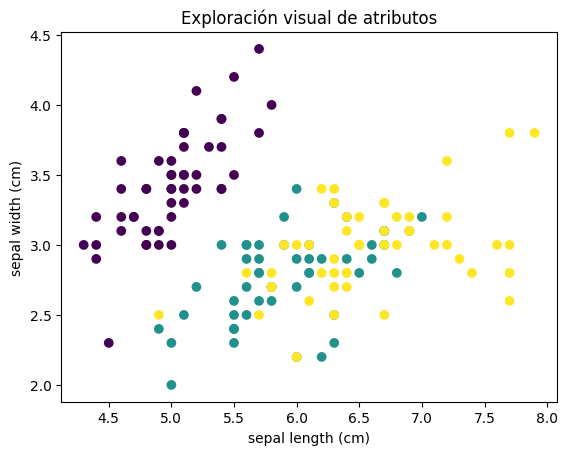

In [ ]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['target'])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('Exploración visual de atributos')
plt.show()

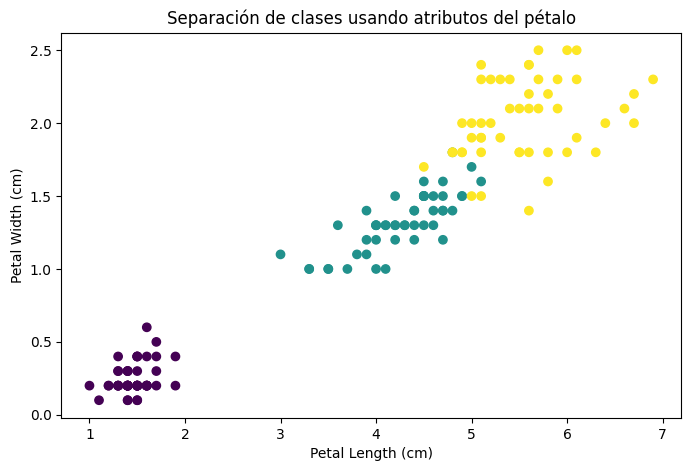

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['target']
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Separación de clases usando atributos del pétalo')

plt.show()

*Para este análisis se probaron distintas combinaciones de atributos del dataset Iris. La combinación formada por petal length y petal width presentó la mejor separación visual entre las clases. Se observa que la clase Setosa forma un grupo claramente diferenciado y separado de las demás especies. En cambio, Versicolor y Virginica presentan una ligera superposición, aunque siguen siendo distinguibles. Por ello, considero que Setosa es la clase más fácil de separar utilizando únicamente dos atributos.*

*La combinación petal length y petal width proporcionó la mejor separación visual entre las clases del dataset Iris.*

## 🧠 Desafío 2 — Vence al Modelo

Tu objetivo es **superar el accuracy obtenido por el modelo base** entrenado en esta actividad.

### Reglas:
- Podés modificar SOLO uno de estos elementos:
  - el tamaño del conjunto de prueba,
  - el modelo (cambiar LogisticRegression por otro simple),
  - o los atributos utilizados (seleccionar solo algunos).

### Pasos:
1. Elegí qué vas a modificar.
2. Entrená nuevamente el modelo.
3. Compará tu accuracy con el original.
4. Explicá por qué creés que tu cambio mejoró o empeoró el rendimiento.

### Bonus:
- Si lográs superar el accuracy por más de 5%, ganás el **Logro: Ajustador de Modelos**.

In [ ]:
X_new = X[:, 2:4]

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

new_accuracy = model.score(X_test, y_test)

print("Nuevo accuracy:", new_accuracy)

Nuevo accuracy: 1.0



*Para este desafío decidí modificar los atributos utilizados por el modelo, seleccionando únicamente las variables petal length y petal width. Esta decisión se basó en el análisis realizado en el Desafío 1, donde dichas variables mostraron la mejor separación visual entre las clases del dataset Iris.*

*El modelo original obtuvo un accuracy de 1.0 y el nuevo modelo también alcanzó un accuracy de 1.0. Esto significa que el modelo clasificó correctamente el 100% de las muestras del conjunto de prueba en ambos casos. Por lo tanto, el rendimiento no mejoró ni empeoró al reducir la cantidad de atributos utilizados.*

*Este resultado sugiere que las características asociadas a los pétalos contienen la información más relevante para distinguir las especies de flores presentes en el dataset. Además, demuestra que es posible simplificar el modelo manteniendo el mismo nivel de precisión.*

*No fue posible superar el accuracy original, ya que este ya correspondía al valor máximo alcanzable (100%). Sin embargo, el experimento permitió comprobar que un subconjunto reducido de atributos puede ofrecer el mismo desempeño que el conjunto completo de variables.*

# 📊 Rúbrica de Evaluación – Actividad Práctica Clase 1

| Criterio | Excelente (5) | Bueno (4) | Aceptable (3) | Insuficiente (1–2) |
|---------|---------------|-----------|---------------|---------------------|
| **Comprensión conceptual** | Explica claramente supervisado/no supervisado y el flujo de ML con ejemplos propios. | Explica correctamente pero sin ejemplos propios. | Explica parcialmente o con confusiones menores. | Explicación incompleta o incorrecta. |
| **Correcta ejecución del código** | Todo el código funciona, está ordenado y comentado. | Código funcional con mínimos errores o sin comentarios. | Código funcional pero desordenado o poco claro. | Código no funcional o incompleto. |
| **Interpretación de resultados** | Interpreta métricas y predicciones con claridad y profundidad. | Interpretación correcta pero superficial. | Interpretación parcial o con errores menores. | No interpreta o interpreta incorrectamente. |
| **Reflexión crítica** | Responde preguntas con análisis propio y justificaciones sólidas. | Responde adecuadamente pero sin profundidad. | Respuestas breves o poco reflexivas. | Respuestas vagas o incorrectas. |
| **Creatividad en desafíos** | Propone ideas originales y experimenta más allá de lo pedido. | Cumple el desafío con una solución correcta. | Cumple parcialmente el desafío. | No completa el desafío. |

### **Puntaje total:** 25 puntos  
- **23–25:** Sobresaliente  
- **19–22:** Muy bueno  
- **15–18:** Aprobado  
- **<15:** Requiere revisión  